In [2]:
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import setuptools
import packaging
import pkg_resources
pkg_resources.packaging = packaging
import torch.optim as optim
import torch.nn as nn
import clip 
from sklearn.model_selection import train_test_split
import random
import os
import numpy as np
import matplotlib.pyplot as plt

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 
seed_everything(42)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3548\1497508394.py:7: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [4]:
class APODDataset(Dataset):
    def __init__(self, dataframe, preprocess):
        self.df = dataframe.reset_index(drop=True) 
        self.preprocess = preprocess

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = self.preprocess(Image.open(row['image_path']))
        caption = str(row['phil_caption']) if 'phil_caption' in row else str(row['caption'])
        text = clip.tokenize(caption, truncate=True)[0]
        
        return image, text

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

df = pd.read_csv("dataset_clip_philosophical.csv")


train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


train_ds = APODDataset(train_df, preprocess)
val_ds = APODDataset(val_df, preprocess)
test_ds = APODDataset(test_df, preprocess)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

cuda
Train: 8615 | Val: 1077 | Test: 1077


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Entrenando en: {device}")

model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

if device == "cpu":
    model.float()
else:
    model.float() 

model.train()

Entrenando en: cuda


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

Iniciando entrenamiento en cuda...


Epoch 0 [Train]: 100%|██████████| 270/270 [35:22<00:00,  7.86s/it, loss=1.1] 



>> Epoch 0 Finalizada | Train Loss: 1.9580 | Val Loss: 1.9554



Epoch 1 [Train]: 100%|██████████| 270/270 [35:55<00:00,  7.98s/it, loss=1.25] 



>> Epoch 1 Finalizada | Train Loss: 1.2691 | Val Loss: 2.1176



...


>> Epoch 2 Finalizada | Train Loss: 0.7680 | Val Loss: 2.5171



Epoch 3 [Train]: 100%|██████████| 270/270 [33:44<00:00,  7.50s/it, loss=0.168] 



>> Epoch 3 Finalizada | Train Loss: 0.4334 | Val Loss: 3.1300



Epoch 4 [Train]: 100%|██████████| 270/270 [33:46<00:00,  7.51s/it, loss=6.16e-5]



>> Epoch 4 Finalizada | Train Loss: 0.2358 | Val Loss: 3.4118

Ejecutando evaluación final en el Test Set...
RESULTADO FINAL - Test Loss: 3.3752
Modelo guardado exitosamente.


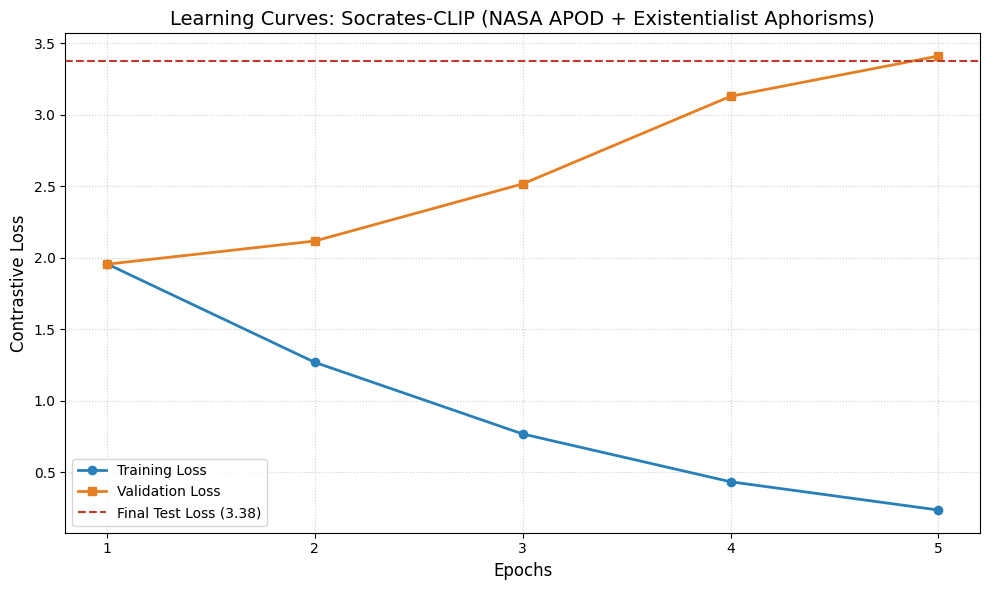

In [ ]:
epochs = 5
optimizer = optim.AdamW(model.parameters(), lr=5e-6, betas=(0.9, 0.98), eps=1e-6, weight_decay=0.2)
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

# Listas para métricas
train_losses = []
val_losses = []

print(f"Iniciando entrenamiento en {device}...")

for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")
    for images, texts in pbar:
        images = images.to(device)
        texts = texts.to(device)

        optimizer.zero_grad()

        # Forward pass
        logits_per_image, logits_per_text = model(images, texts)
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)

        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_train_loss += loss.item()
        pbar.set_postfix({"loss": loss.item()})

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)


    model.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        for images, texts in val_loader:
            images = images.to(device)
            texts = texts.to(device)
            
            logits_per_image, logits_per_text = model(images, texts)
            ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
            
            val_loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
            total_val_loss += val_loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"\n>> Epoch {epoch} Finalizada | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")

print("Ejecutando evaluación final en el Test Set...")
model.eval()
total_test_loss = 0
with torch.no_grad():
    for images, texts in test_loader:
        images = images.to(device)
        texts = texts.to(device)
        logits_per_image, logits_per_text = model(images, texts)
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
        total_test_loss += loss.item()

final_test_loss = total_test_loss / len(test_loader)
print(f"RESULTADO FINAL - Test Loss: {final_test_loss:.4f}")

torch.save(model.state_dict(), "socrates_clip_weights.pt")
print("Modelo guardado exitosamente.")

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='#2980b9', marker='o', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='#e67e22', marker='s', linewidth=2)

plt.axhline(y=final_test_loss, color='#c0392b', linestyle='--', label=f'Final Test Loss ({final_test_loss:.2f})')

plt.title('Learning Curves: Socrates-CLIP (NASA APOD + Existentialist Aphorisms)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Contrastive Loss', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("socrates_clip_learning_curves.png", dpi=300)
plt.show()

In [10]:
print("Ejecutando evaluación final en el Test Set...")
model.eval()
total_test_loss = 0
with torch.no_grad():
    for images, texts in test_loader:
        images = images.to(device)
        texts = texts.to(device)
        logits_per_image, logits_per_text = model(images, texts)
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
        total_test_loss += loss.item()

final_test_loss = total_test_loss / len(test_loader)
print(f"RESULTADO FINAL - Test Loss: {final_test_loss:.4f}")

Ejecutando evaluación final en el Test Set...
RESULTADO FINAL - Test Loss: 3.2762


In [13]:
def evaluate_metrics(model, dataloader, device):
    model.eval()
    all_image_features = []
    all_text_features = []

    with torch.no_grad():
        for images, texts in dataloader:
            images = images.to(device)
            texts = texts.to(device)

            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)

            image_features /= image_features.norm(dim=-1, keepdim=True)
            text_features /= text_features.norm(dim=-1, keepdim=True)

            all_image_features.append(image_features)
            all_text_features.append(text_features)

    all_image_features = torch.cat(all_image_features)
    all_text_features = torch.cat(all_text_features)

    sim_matrix = (all_image_features @ all_text_features.T).cpu()

    ranks = []
    for i in range(sim_matrix.size(0)):
        sims = sim_matrix[i]
        sorted_indices = torch.argsort(sims, descending=True)
        rank = (sorted_indices == i).nonzero(as_tuple=True)[0].item()
        ranks.append(rank)

    ranks = torch.tensor(ranks)
    
    r1 = (ranks < 1).float().mean().item() * 100
    r5 = (ranks < 5).float().mean().item() * 100
    r10 = (ranks < 10).float().mean().item() * 100
    p1 = (ranks < 1).float().mean().item() * 100 
    p5 = ((ranks < 5).float() / 5.0).mean().item() * 100
    p10 = ((ranks < 10).float() / 10.0).mean().item() * 100
    mrr = (1.0 / (ranks.float() + 1)).mean().item()

    return {"R@1": r1, "R@5": r5, "R@10": r10, "MRR": mrr, "p@1":p1, "p@5":p5,"p@10":p10}

metrics = evaluate_metrics(model, test_loader, device)
print(f"\nResultados en Test Set:")
print(f"Recall@1: {metrics['R@1']:.2f}% | Recall@5: {metrics['R@5']:.2f}% | Recall@10: {metrics['R@10']:.4f}| MRR: {metrics['MRR']:.4f} | Precision@1: {metrics['p@1']:.4f}| Precision@5: {metrics['p@5']:.4f}| Precision@10: {metrics['p@10']:.4f}")


Resultados en Test Set:
Recall@1: 14.48% | Recall@5: 28.51% | Recall@10: 34.3547| MRR: 0.2147 | Precision@1: 14.4847| Precision@5: 5.7010| Precision@10: 3.4355


In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Entrenando en: {device}")

model_clip_base, preprocess = clip.load("ViT-B/32", device=device, jit=False)

if device == "cpu":
    model_clip_base.float()
else:
    model_clip_base.float() 

model_clip_base.eval()

metrics = evaluate_metrics(model_clip_base, test_loader, device)
print(f"\nResultados en Test Set:")
print(f"Recall@1: {metrics['R@1']:.2f}% | Recall@5: {metrics['R@5']:.2f}% | Recall@10: {metrics['R@10']:.4f}| MRR: {metrics['MRR']:.4f}")

Entrenando en: cuda

Resultados en Test Set:
Recall@1: 12.16% | Recall@5: 26.37% | Recall@10: 33.6119| MRR: 0.1931


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3548\2153781364.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_socrates.load_state_dict(torch.load(my_model_path, map

["3. Leonid Meteors Through Orion: In the infinite darkness, a meteor's streak is a momentary connecti", '3. Geminid Meteors: **In the snowy forest, meteors streak like fleeting sparks, bridging the gap bet', '1. The gegenschein, a faint glow opposite the sun, reveals the celestial dance of interplanetary dus', 'Comet McNaught, a brilliant spark of cosmic dust, shines briefly, a fleeting beauty in our sky. Its ', '4. Beyond the horizons of Slovakia, meteors paint the sky with fiery trails, their paths guided by t']
['2. A fireball blazes, orange glow lingering,', '2. **2023 CX1 Meteor Flash:**', "4. From the depths of the cosmos, a meteorite's arrival is a reminder that the universe can bring bo", "2. In the Mojave Desert, a meteor's flash illuminates the celestial canvas, momentarily outshining t", 'Amidst the cosmic ballet, meteors dance with planes, a galaxy arching overhead.']


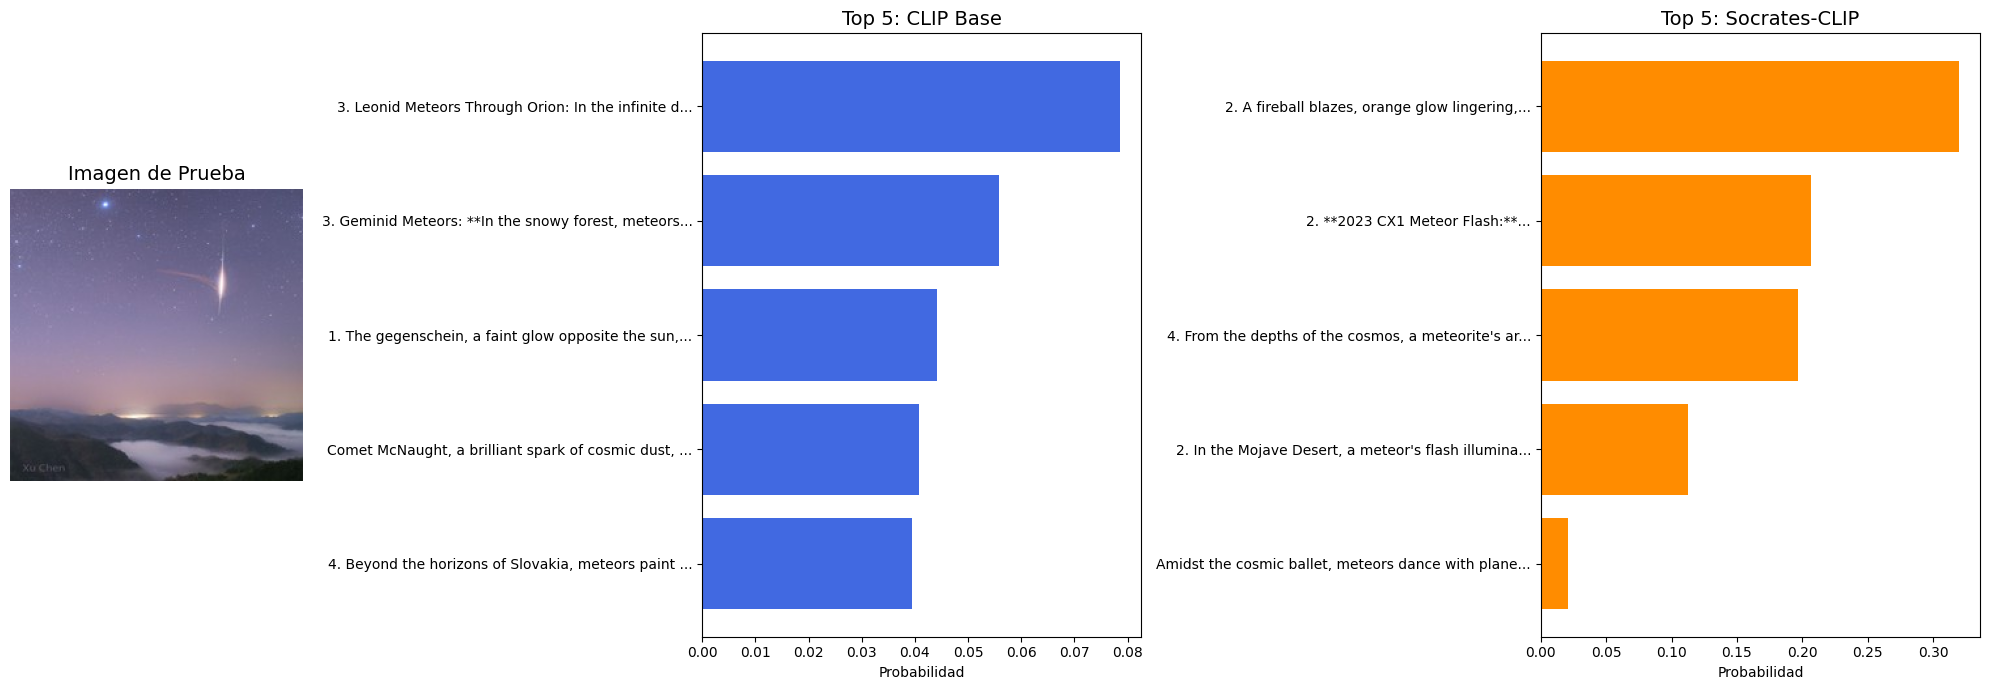

In [8]:
def compare_models(image_path, text_corpus, my_model_path, device="cuda" if torch.cuda.is_available() else "cpu"):
    model_base, preprocess = clip.load("ViT-B/32", device=device)
    
    model_socrates, _ = clip.load("ViT-B/32", device=device)
    model_socrates.load_state_dict(torch.load(my_model_path, map_location=device))
    
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    text_tokens = clip.tokenize(text_corpus, truncate=True).to(device)
    
    results = {}
    models = {"CLIP Base": model_base, "Socrates-CLIP": model_socrates}

    with torch.no_grad():
        for name, model in models.items():
            model.eval()
            img_feat = model.encode_image(image)
            txt_feat = model.encode_text(text_tokens)
            
            img_feat /= img_feat.norm(dim=-1, keepdim=True)
            txt_feat /= txt_feat.norm(dim=-1, keepdim=True)
            
            probs = (100.0 * img_feat @ txt_feat.T).softmax(dim=-1).cpu().numpy()[0]
            
            top5_idx = probs.argsort()[-5:][::-1]
            results[name] = [(text_corpus[i], probs[i]) for i in top5_idx]

    fig, axes = plt.subplots(1, 3, figsize=(20, 7), gridspec_kw={'width_ratios': [1, 1.5, 1.5]})
    
    axes[0].imshow(Image.open(image_path))
    axes[0].set_title("Imagen de Prueba", fontsize=14)
    axes[0].axis('off')
    
    for i, (name, top_preds) in enumerate(results.items()):
        ax = axes[i+1]
        texts = [p[0][:50] + "..." for p in top_preds]
        print([p[0][:100] for p in top_preds])
        scores = [p[1] for p in top_preds]
        
        ax.barh(range(5), scores, color='royalblue' if "Base" in name else 'darkorange')
        ax.set_yticks(range(5))
        ax.set_yticklabels(texts)
        ax.invert_yaxis()
        ax.set_title(f"Top 5: {name}", fontsize=14)
        ax.set_xlabel("Probabilidad")

    plt.tight_layout()
    plt.show()

corpus = list(test_df['phil_caption']) 
compare_models("apod_images_224/2026-01-12.jpg", corpus, "socrates_clip_weights.pt")